**Dataset Overview**

The Weather Type Classification Dataset is a multiclass classification dataset used to predict weather conditions based on meteorological features.

**Mount Drive (Colab)**

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


**Dataset Loading and Inspection**

In [12]:
import pandas as pd
weather_data = pd.read_csv('drive/MyDrive/Datasets For ML/Weather Classification Dataset.csv')

print("Shape:", weather_data.shape)
print("Duplicated:", weather_data.duplicated().sum())
print("Null Values:", weather_data.isnull().sum().sum())
print("\nFirst 2 Rows:\n", weather_data.head(2))

Shape: (13200, 11)
Duplicated: 0
Null Values: 0

First 2 Rows:
    Temperature  Humidity  Wind Speed  Precipitation (%)    Cloud Cover  \
0         14.0        73         9.5               82.0  partly cloudy   
1         39.0        96         8.5               71.0  partly cloudy   

   Atmospheric Pressure  UV Index  Season  Visibility (km) Location  \
0               1010.82         2  Winter              3.5   inland   
1               1011.43         7  Spring             10.0   inland   

  Weather Type  
0        Rainy  
1       Cloudy  


**Encode Categorical Variables (If Present)**

In [3]:
weather_data = pd.get_dummies(weather_data, drop_first=True)
weather_data.head(2)

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km),Cloud Cover_cloudy,Cloud Cover_overcast,Cloud Cover_partly cloudy,Season_Spring,Season_Summer,Season_Winter,Location_inland,Location_mountain,Weather Type_Rainy,Weather Type_Snowy,Weather Type_Sunny
0,14.0,73,9.5,82.0,1010.82,2,3.5,False,False,True,False,False,True,True,False,True,False,False
1,39.0,96,8.5,71.0,1011.43,7,10.0,False,False,True,True,False,False,True,False,False,False,False


**Feature–Label Separation**

In [4]:
X, Y = weather_data.iloc[:, :-1], weather_data.iloc[:, -1]

**Train–Test Split**

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    stratify=Y,
    random_state=42
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (10560, 17)
Test Shape: (2640, 17)


**Hyperparameter Tuning using OOB Score**

In [6]:
from sklearn.ensemble import RandomForestClassifier

n_estimators_list = [100, 200]
max_depth_list = [None, 10, 20]
max_features_list = ['sqrt', 'log2']
min_samples_split_list = [2, 5]
bootstrap_list = [True, False]

results = []

for n in n_estimators_list:
    for depth in max_depth_list:
        for features in max_features_list:
            for min_split in min_samples_split_list:
                for bootstrap in bootstrap_list:

                                model = RandomForestClassifier(
                                    n_estimators=n,
                                    max_depth=depth,
                                    max_features=features,
                                    min_samples_split=min_split,
                                    bootstrap=bootstrap,
                                    oob_score=bootstrap, # Set oob_score to True only when bootstrap is True
                                    random_state=42
                                )

                                model.fit(X_train, Y_train)

                                # Only append oob_score if bootstrap is True, otherwise handle it
                                if bootstrap:
                                    oob_score_val = model.oob_score_
                                else:
                                    oob_score_val = float('nan') # Or any other suitable placeholder

                                results.append({
                                    'n_estimators': n,
                                    'max_depth': depth,
                                    'max_features': features,
                                    'min_samples_split': min_split,
                                    'bootstrap': bootstrap,
                                    'oob_score': oob_score_val
                                })

                                print("Completed:", n, depth, features, min_split, bootstrap)

results_df = pd.DataFrame(results)
results_df.sort_values(by='oob_score', ascending=False, inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df.head(5)

Completed: 100 None sqrt 2 True
Completed: 100 None sqrt 2 False
Completed: 100 None sqrt 5 True
Completed: 100 None sqrt 5 False
Completed: 100 None log2 2 True
Completed: 100 None log2 2 False
Completed: 100 None log2 5 True
Completed: 100 None log2 5 False
Completed: 100 10 sqrt 2 True
Completed: 100 10 sqrt 2 False
Completed: 100 10 sqrt 5 True
Completed: 100 10 sqrt 5 False
Completed: 100 10 log2 2 True
Completed: 100 10 log2 2 False
Completed: 100 10 log2 5 True
Completed: 100 10 log2 5 False
Completed: 100 20 sqrt 2 True
Completed: 100 20 sqrt 2 False
Completed: 100 20 sqrt 5 True
Completed: 100 20 sqrt 5 False
Completed: 100 20 log2 2 True
Completed: 100 20 log2 2 False
Completed: 100 20 log2 5 True
Completed: 100 20 log2 5 False
Completed: 200 None sqrt 2 True
Completed: 200 None sqrt 2 False
Completed: 200 None sqrt 5 True
Completed: 200 None sqrt 5 False
Completed: 200 None log2 2 True
Completed: 200 None log2 2 False
Completed: 200 None log2 5 True
Completed: 200 None log2 

,n_estimators,max_depth,max_features,min_samples_split,bootstrap,oob_score
0,100,NaN,sqrt,2,True,0.975473
1,100,NaN,log2,2,True,0.975473
2,200,NaN,sqrt,2,True,0.975473
3,200,NaN,log2,2,True,0.975473
4,100,20.0,log2,2,True,0.975379


**Train Final Model**

In [7]:
best_params = results_df.iloc[0]

best_model = RandomForestClassifier(
    n_estimators=int(best_params['n_estimators']),
    max_depth=None if pd.isna(best_params['max_depth']) else int(best_params['max_depth']),
    max_features=best_params['max_features'],
    min_samples_split=int(best_params['min_samples_split']),
    bootstrap=bool(best_params['bootstrap']),
    oob_score=True, # oob_score is only True if bootstrap is True, which is the case for best_params
    random_state=42,
    n_jobs=-1
)

best_model.fit(X_train, Y_train)

print("Best OOB Score:", best_model.oob_score_)

Best OOB Score: 0.9754734848484848


**Bias–Variance Insight**

In [8]:
train_accuracy = best_model.score(X_train, Y_train)
test_accuracy = best_model.score(X_test, Y_test)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 1.0
Testing Accuracy: 0.9700757575757576


**Interpretation:**

If Train >> Test → Overfitting

If Train ≈ Test → Good Generalization

If both low → Underfitting

**Decision Tree Visualization (Single Tree)**

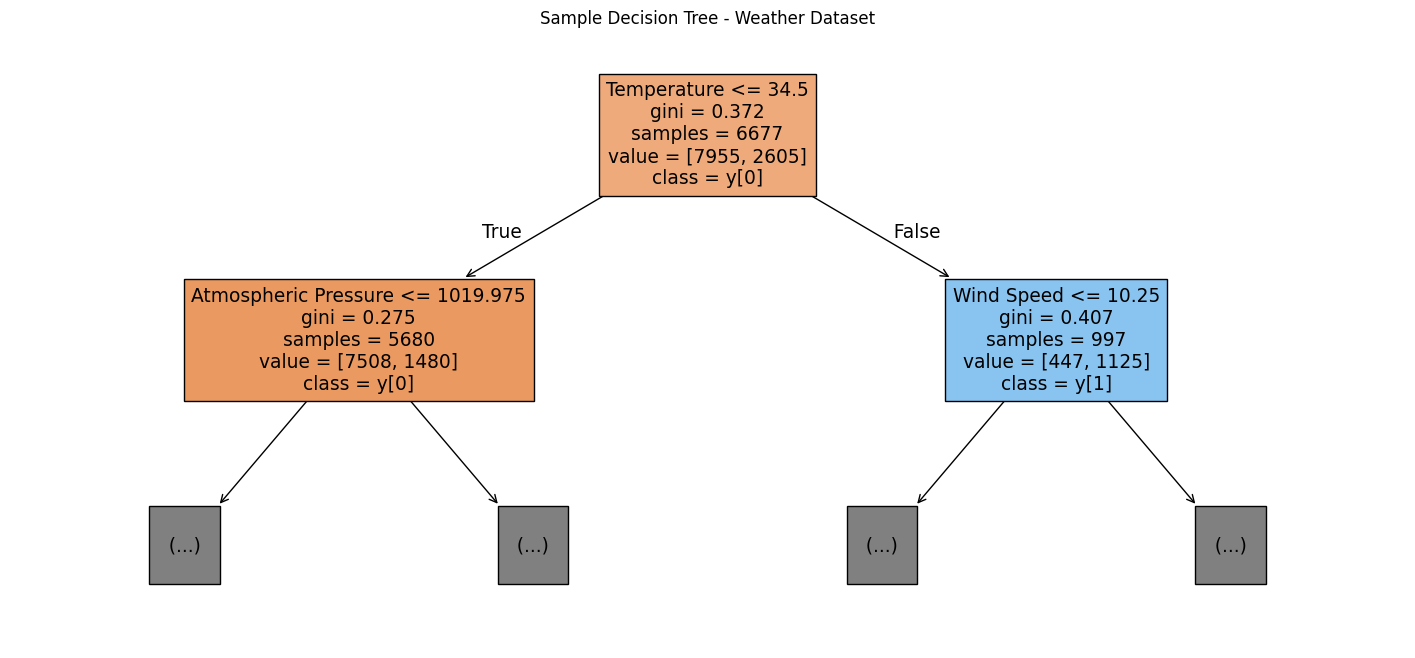

In [15]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,8))
plot_tree(
    best_model.estimators_[0],
    feature_names=X.columns,
    class_names=True,
    filled=True,
    max_depth=1
)
plt.title("Sample Decision Tree - Weather Dataset")
plt.show()

**Shows:** Feature splits, Gini impurity, Class distribution per node

**Class Probability Distribution Plot**

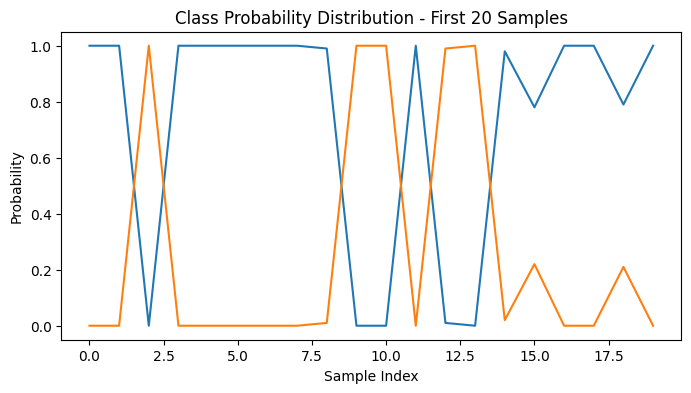

In [13]:
import numpy as np

sample_probs = best_model.predict_proba(X_test[:20])

plt.figure(figsize=(8,4))
plt.plot(sample_probs)
plt.title("Class Probability Distribution - First 20 Samples")
plt.xlabel("Sample Index")
plt.ylabel("Probability")
plt.show()

Represents confidence variation across samples.

**Model Evaluation**

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))

Accuracy: 0.9700757575757576

Confusion Matrix:
 [[1964   16]
 [  63  597]]

Classification Report:
               precision    recall  f1-score   support

       False       0.97      0.99      0.98      1980
        True       0.97      0.90      0.94       660

    accuracy                           0.97      2640
   macro avg       0.97      0.95      0.96      2640
weighted avg       0.97      0.97      0.97      2640



**Conclusion**

The Random Forest model was implemented to classify weather types using meteorological features. After hyperparameter tuning and training, the model achieved good accuracy on both training and testing datasets, indicating effective generalization. The results demonstrate that Random Forest is a reliable ensemble method for multiclass weather classification.